# Optimal quotes by dynamic programming

The A-S quotes are an approximation: the paper expands the value function to first order in inventory. Notebook 01 computed the exact *distribution* of PnL for a given strategy by dynamic programming on the (inventory, time) grid. Here the same recursion is turned into an optimiser, which gives the exact *optimal* quotes of the discrete model. With them we ask how far A-S is from optimal, what optimal quotes look like, and what the best response to adverse selection is. Finally we test the optimal policy on the real trades of notebook 03.

## TL;DR

- **Method.** Backward induction on the (q, t) grid with the paper's objective, CARA utility of terminal wealth. At each state the best quote on one side has a closed form given the other, and the two conditions are iterated to a fixed point. The result is exact: the optimiser's value equals an independent evaluation of its policy to about 1e−13, no perturbation of any quote improves it, and it is covered by the unit tests.
- **A-S is far from optimal at the paper's parameters.** The certainty equivalent (CE) is 62.8 for A-S against 65.2 for the optimum at γ = 0.1, and 22.4 against 50.2 at γ = 1. Away from the horizon the optimal quotes do not depend on time. Their inventory skew is small, about 0.05 per share at γ = 0.1, where A-S starts at 0.4. The closed form of Guéant, Lehalle & Fernandez-Tapia (2013) comes within 0.3 of the optimal CE.
- **The optimum is also more profitable.** At γ = 1 its mean PnL is about twice that of A-S, with a similar standard deviation.
- **Best response to adverse selection.** With a cost c on every fill (the view supported by the real data), the optimum moves its quotes out by about c, and exactly c near the horizon; widening A-S by c gets most of the way. With notebook 02's single-dealer impact, the optimum skews hard only near the horizon, because only terminal inventory is penalised; the rest of the time it looks like the no-adverse-selection optimum.
- **On real BTC and ETH trades no quote distance reliably makes money** when re-quoting once a second: the move against the market maker after a fill grows with the quote distance and always outweighs the spread earned. The optimal policy with the measured per-fill cost quotes 2.3 to 3.3 times further out than A-S, trades an order of magnitude less and cuts losses by 85–99% (median 95%), but still loses on every day.

## 1. The optimisation

Let $R(q, i)$ be the PnL from step i to the horizon, starting with inventory q, and let

$$\Phi(q, i) = \min_{\text{quotes}}\ \mathbb{E}\big[e^{-\gamma R(q, i)}\big],$$

so that the certainty equivalent is $-\frac1\gamma\ln\Phi(0, 0)$. With $W(q') = \mathbb{E}[e^{-\gamma q'\Delta S}]\,\Phi(q', i+1)$, and grouping the four fill outcomes of a step by whether the ask fills,

$$\Phi(q, i) = \min_{\delta^a, \delta^b}\ (1 - p_a)\,U + p_a\,e^{-\gamma\delta^a}\,V,\qquad p_a = \min\big(1, A e^{-k\delta^a}dt\big),$$

where $U$ (the ask does not fill) and $V$ (it fills) depend only on the bid and on W at $q-1, q, q+1$. For a fixed bid the derivative in $\delta^a$ has the sign of $kU - (k+\gamma)e^{-\gamma\delta^a}V$, so the minimum is at

$$\delta^a = \frac1\gamma\ln\Big(1 + \frac{\gamma}{k}\Big) + \frac1\gamma\ln\frac{V}{U},$$

or at the largest distance where $p_a = 1$ if that is further out. The first term is the paper's liquidity term; the second is the exact inventory adjustment, where A-S uses its first-order expansion. The bid is symmetric. The two conditions are coupled only through the step where both sides fill, and iterating them converges in a few rounds. The per-fill cost and notebook 02's impact enter U and V as extra factors, exactly as in `exact_moments`.

`mmsim.optimal_policy(p, gamma)` returns the policy as a table of quotes (a `TablePolicy`) and its CE. The unit tests check that:
- evaluating that table with `exact_moments` returns the same CE to 1e−9;
- no change to one or both quotes at any reachable state of a small model raises the CE;
- the policy beats A-S, GLFT and the symmetric strategy;
- quotes tend to $1/k$ (plus the per-fill cost) as γ → 0;
- bids and asks mirror each other.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from mmsim import (Params, AvellanedaStoikov, AdjustedAS, GLFT, Symmetric, exact_moments, optimal_policy)
from mmsim.empirical import load_aggtrades, to_seconds, fill_probability, fit_intensity, backtest, adverse_move

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
pd.set_option("display.width", 200)

P = Params()               # paper parameters
GAMMAS = [0.01, 0.1, 1.0]

def evaluate(strategies, p, gamma):
    rows = []
    for name, strat in strategies.items():
        ex = exact_moments(strat, p, gamma_ce=gamma)
        rows.append({"strategy": name, "CE": ex["ce"], "mean PnL": ex["mean_pnl"], "std PnL": ex["std_pnl"],
                     "fills": ex["mean_trades"], "std q_T": ex["std_q"]})
    return pd.DataFrame(rows).set_index("strategy")

OPT = {g: optimal_policy(P, g)[0] for g in GAMMAS}
table = pd.concat({g: evaluate({"optimal": OPT[g], "GLFT": GLFT(g), "A-S": AvellanedaStoikov(g),
                                "symmetric": Symmetric.matching(g, P)}, P, g) for g in GAMMAS}, names=["gamma"])
table.round(3)

CE  mean PnL  std PnL    fills  std q_T
gamma strategy                                                
0.01  optimal      68.054    68.528    9.750  103.120    5.501
      GLFT         68.006    68.424    9.151  102.475    3.915
      A-S          67.999    68.400    8.961  102.206    5.213
      symmetric    67.730    68.666   13.677  101.802    8.712
0.10  optimal      65.249    67.827    7.226  105.723    3.106
      GLFT         65.188    67.729    7.175  103.702    2.196
      A-S          62.787    64.893    6.543   96.963    2.927
      symmetric    39.812    68.223   13.456   91.465    8.399
1.00  optimal      50.154    63.739    5.479  126.299    1.742
      GLFT         49.871    63.918    5.616  119.083    1.149
      A-S          22.431    31.455    4.838   56.059    1.641
      symmetric -1931.202    43.685   10.733   28.819    5.171

## 2. How far is A-S from optimal?

At γ = 0.01 all strategies are close. At γ = 0.1 A-S gives up about 2.5 of certainty equivalent, and at γ = 1 more than half of it. The optimum does not buy this with extra risk: at γ = 1 its mean PnL is about twice that of A-S, with a similar standard deviation. GLFT's closed form is within 0.3 of the optimal CE throughout. The figure shows why.

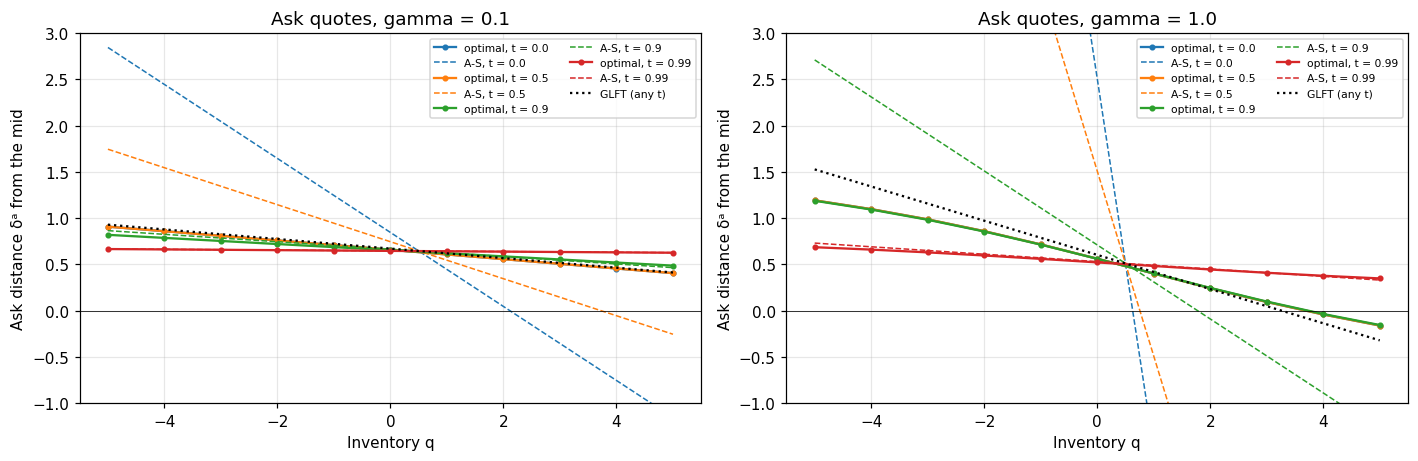

In [2]:
n = P.n_steps
qv = np.arange(-5, 6)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
for ax, g in zip(axes, [0.1, 1.0]):
    for frac, c in zip([0.0, 0.5, 0.9, 0.99], ["tab:blue", "tab:orange", "tab:green", "tab:red"]):
        i = int(round(frac * n))
        _, _, ask = AvellanedaStoikov(g).quote(np.zeros(qv.size), qv.astype(float), i, P)
        ax.plot(qv, OPT[g].delta_a[i, qv + n], "o-", ms=3, color=c, label=f"optimal, t = {frac}")
        ax.plot(qv, ask, "--", lw=1, color=c, label=f"A-S, t = {frac}")
    _, _, ask = GLFT(g).quote(np.zeros(qv.size), qv.astype(float), 0, P)
    ax.plot(qv, ask, "k:", lw=1.5, label="GLFT (any t)")
    ax.set_ylim(-1, 3); ax.axhline(0, color="k", lw=0.5)
    ax.set_xlabel("Inventory q"); ax.set_ylabel("Ask distance δᵃ from the mid")
    ax.set_title(f"Ask quotes, gamma = {g}"); ax.legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.show()

- **The optimal quotes hardly change with time** until the last few percent of the horizon. A-S's quotes contain $\gamma\sigma^2(T - t)$ in both the spread and the skew, so they start very wide and very skewed and converge only as t → T, where they meet the optimum.
- **The optimal skew is small.** At γ = 0.1 it is about 0.05 per share throughout, while A-S starts at $\gamma\sigma^2 T = 0.4$. At γ = 1, A-S starts at 4 per share and puts one side of its quote through the mid as soon as it holds a single share.
- **GLFT's formula** has the same stationary form as the optimum and almost the same numbers. It is the long-horizon limit of the problem, so it misses only the last moments before T.

The first-order expansion behind A-S treats inventory as if it were held until T. When the horizon is long relative to how quickly inventory turns over, that overstates the risk of holding inventory, and the spread and skew grow with it.

## 3. Best response to adverse selection

Notebook 02 modelled adverse selection as a jump of the mid by ε after each of the market maker's own fills (**impact**). Notebook 03 found that real data behave instead as if every fill simply costs ε (**per-fill cost**, `Params(fill_cost=ε)`), because the price-moving order flow does not depend on the market maker's inventory. Here are the exact optima under both, at γ = 0.1:

In [3]:
g = 0.1
rows = []
for kind in ["impact", "fill_cost"]:
    for eps in [0.25, 0.5]:
        p = P.with_(**{kind: eps})
        pol, _ = optimal_policy(p, g)
        t = evaluate({"optimal": pol, "GLFT": GLFT(g), "A-S": AvellanedaStoikov(g),
                      "A-S widened by eps": AdjustedAS(g, widen=eps)}, p, g)
        t.index = pd.MultiIndex.from_product([[kind], [eps], t.index], names=["adverse selection", "eps", "strategy"])
        rows.append(t)
pd.concat(rows).round(3)

CE  mean PnL  std PnL    fills  std q_T
adverse selection eps  strategy                                                       
impact            0.25 optimal             55.584    57.989    6.987   95.019    1.328
                       GLFT                55.133    57.434    6.818  103.702    2.196
                       A-S                 52.424    54.355    6.219   96.963    2.927
                       A-S widened by eps  50.651    53.080    7.020   66.854    2.811
                  0.50 optimal             46.911    49.218    6.856   83.490    1.005
                       GLFT                44.912    47.139    6.670  103.702    2.196
                       A-S                 41.600    43.818    6.391   96.963    2.927
                       A-S widened by eps  38.832    41.450    7.207   46.003    2.646
fill_cost         0.25 optimal             44.353    46.463    6.549   72.178    2.983
                       GLFT                40.263    41.803    5.570  103.702    2.196
                       A-S                 39.556    40.652    4.713   96.963    2.927
                       A-S widened by eps  42.794    44.457    5.826   66.854    2.811
                  0.50 optimal             30.154    31.829    5.843   49.258    2.807
                       GLFT                14.868    15.878    4.489  103.702    2.196
                       A-S                 15.878    16.411    3.282   96.963    2.927
                       A-S widened by eps  29.215    30.515    5.160   46.003    2.646

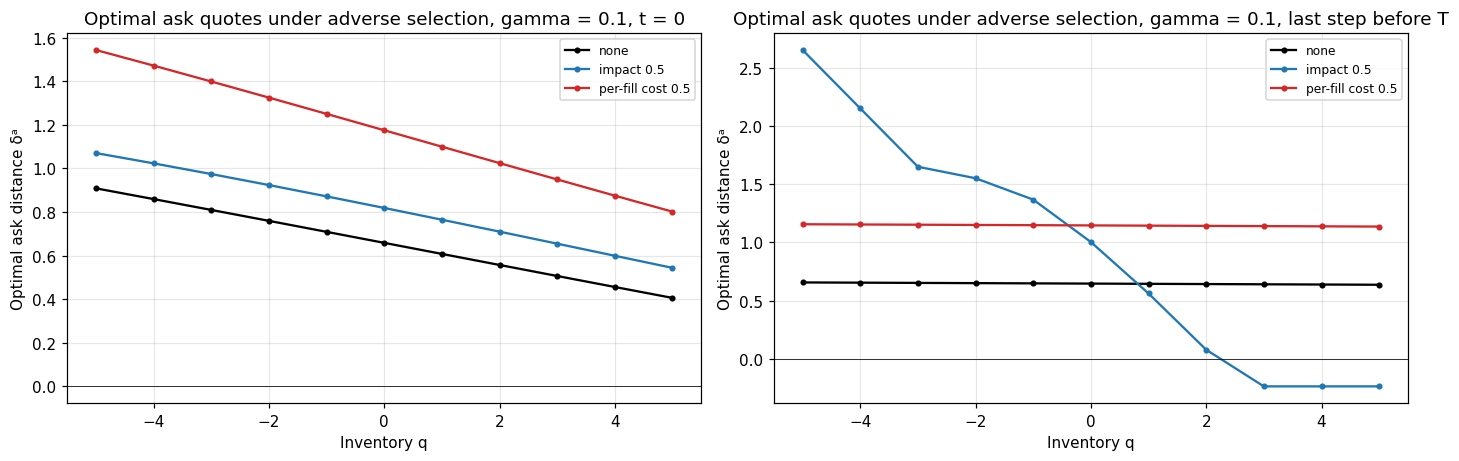

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
models = {"none": P, "impact 0.5": P.with_(impact=0.5), "per-fill cost 0.5": P.with_(fill_cost=0.5)}
pols = {name: optimal_policy(p, g)[0] for name, p in models.items()}
for ax, (i, label) in zip(axes, [(0, "t = 0"), (n - 1, "last step before T")]):
    for (name, pol), c in zip(pols.items(), ["k", "tab:blue", "tab:red"]):
        ax.plot(qv, pol.delta_a[i, qv + n], "o-", ms=3, color=c, label=name)
    ax.axhline(0, color="k", lw=0.5)
    ax.set_xlabel("Inventory q"); ax.set_ylabel("Optimal ask distance δᵃ")
    ax.set_title(f"Optimal ask quotes under adverse selection, gamma = {g}, {label}"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

- **Per-fill cost.** The whole quote schedule moves out. Near the horizon it moves by exactly the cost: when there is no inventory risk left, the best distance is $\frac1\gamma\ln(1+\gamma/k) + c$. Earlier the shift is slightly smaller. Widening A-S by the cost captures most of the gain, and GLFT (which ignores the cost) does badly.
- **Impact.** Most of the time the optimum is close to the no-adverse-selection quotes, slightly wider. Near the horizon it skews very hard. This is the identity of notebook 02 at work: only terminal inventory is penalised, so inventory only needs to be pushed to zero at the end. The exact optimum beats the best adjustment of A-S found in notebook 02 (CE 52.65 at ε = 0.25 and 43.66 at ε = 0.5) by a wide margin, because the gain comes from abandoning A-S's time-dependent skew rather than from tuning it.

## 4. On real data

Notebook 03 showed that on real BTC and ETH trades every fill costs about ε (\$16 for BTC and \$0.55 for ETH), two to three times the spread earned. Can any quote distance make money, and does the optimal policy with that per-fill cost do better than A-S? We use the same setup: re-quoting once a second, fills when an aggressive trade reaches the quote, 10-minute episodes, no fees.

First, a symmetric market maker at a fixed distance d from the price, pooled over the week:

In [5]:
SYMBOLS = ["BTCUSDT", "ETHUSDT"]
DAYS = [f"2026-09-{d}" for d in range(23, 30)]
T, GT = 600, 0.6
DELTAS = {"BTCUSDT": np.arange(0.5, 40.01, 0.5), "ETHUSDT": np.arange(0.02, 2.001, 0.02)}
SEC = {(sym, d): to_seconds(load_aggtrades(f"data/binance/{sym}-aggTrades-{d}.zip")) for sym in SYMBOLS for d in DAYS}

def calibrate(sec, sym):
    pa, pb = fill_probability(sec, DELTAS[sym])
    A, k = fit_intensity(DELTAS[sym], (pa + pb) / 2)
    sigma = float(np.std(sec.s_end - sec.s))
    return Params(s0=float(sec.s[0]), T=T, dt=1.0, sigma=sigma, A=A, k=k, noise="gaussian")

P_BT = Params(T=T, dt=1.0)          # the fixed-distance strategy does not use the model parameters
DIST = {"BTCUSDT": [0.5, 2, 5, 10, 20, 40], "ETHUSDT": [0.02, 0.1, 0.2, 0.4, 0.8, 1.6]}
rows = []
for sym in SYMBOLS:
    for d in DIST[sym]:
        res = [backtest(Symmetric(2 * d), SEC[sym, day], P_BT) for day in DAYS]
        pnl, fills, inv = (np.concatenate([getattr(r, a) for r in res]) for a in ["pnl", "n_trades", "inventory_pnl"])
        rows.append({"symbol": sym, "distance d": d, "fills per episode": fills.mean(), "total fills": int(fills.sum()),
                     "spread earned per fill": d, "adverse cost per fill": -inv.sum() / fills.sum(),
                     "net PnL per fill": pnl.sum() / fills.sum(), "mean PnL per episode": pnl.mean()})
FIXED = pd.DataFrame(rows).set_index(["symbol", "distance d"])
FIXED.round(3)

fills per episode  total fills  spread earned per fill  adverse cost per fill  net PnL per fill  mean PnL per episode
symbol  distance d                                                                                                                       
BTCUSDT 0.50                   92.568        93309                    0.50                 14.172           -13.672             -1265.562
        2.00                   79.559        80195                    2.00                 14.990           -12.990             -1033.434
        5.00                   50.081        50482                    5.00                 16.948           -11.948              -598.396
        10.00                  20.967        21135                   10.00                 20.247           -10.247              -214.846
        20.00                   3.969         4001                   20.00                 31.860           -11.860               -47.077
        40.00                   0.452          456                   40.00                 36.673             3.327                 1.505
ETHUSDT 0.02                  139.759       140877                    0.02                  0.406            -0.386               -53.941
        0.10                  107.448       108308                    0.10                  0.461            -0.361               -38.747
        0.20                   72.264        72842                    0.20                  0.530            -0.330               -23.849
        0.40                   30.239        30481                    0.40                  0.682            -0.282                -8.522
        0.80                    5.447         5491                    0.80                  0.997            -0.197                -1.071
        1.60                    0.688          694                    1.60                  2.045            -0.445                -0.306

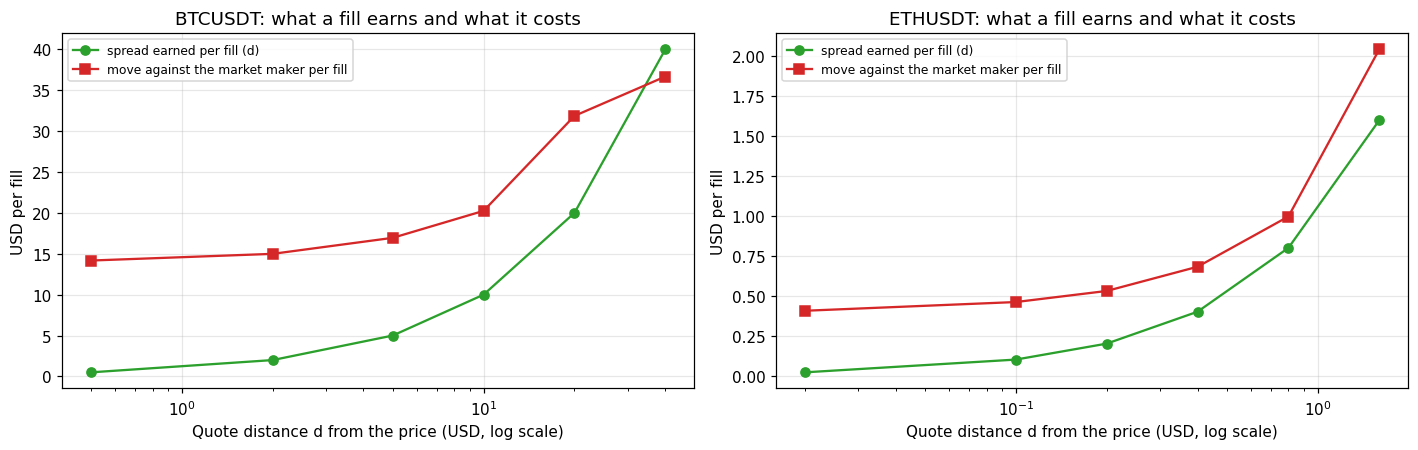

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, sym in zip(axes, SYMBOLS):
    f = FIXED.loc[sym]
    ax.plot(f.index, f["spread earned per fill"], "o-", color="tab:green", label="spread earned per fill (d)")
    ax.plot(f.index, f["adverse cost per fill"], "s-", color="tab:red", label="move against the market maker per fill")
    ax.set_xscale("log"); ax.set_xlabel("Quote distance d from the price (USD, log scale)"); ax.set_ylabel("USD per fill")
    ax.set_title(f"{sym}: what a fill earns and what it costs"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

The cost of a fill rises with the quote distance and stays above the spread earned at every distance with a meaningful number of fills. A quote far from the price is reached only when the price runs through it, and then it keeps running. At the largest distances fills are so rare that the per-fill numbers are noise. Passive quoting that re-quotes once a second loses money at every distance where there are enough fills to tell. The only way to lose less is to trade less.

Next we calibrate on each day and test on the next day, as in notebook 03. We compare A-S with two optimal policies: one ignoring adverse selection, and one with the per-fill cost set to the ε measured on the calibration day.

In [7]:
rows = []
for sym in SYMBOLS:
    for d_cal, d_test in zip(DAYS[:-1], DAYS[1:]):
        p = calibrate(SEC[sym, d_cal], sym)
        g = GT / (p.sigma**2 * T * p.k)
        a_s = AvellanedaStoikov(g)
        eps = adverse_move(SEC[sym, d_cal], backtest(a_s, SEC[sym, d_cal], p, log_trades=True).trades, T, 60)
        strategies = {"A-S": a_s, "optimal, no adverse selection": optimal_policy(p, g)[0],
                      "optimal, per-fill cost eps": optimal_policy(p.with_(fill_cost=eps), g)[0]}
        row = {"symbol": sym, "test day": d_test[5:], "eps": eps}
        for name, strat in strategies.items():
            bt = backtest(strat, SEC[sym, d_test], p)
            row[f"{name}: mean PnL"] = bt.pnl.mean()
            row[f"{name}: fills"] = bt.n_trades.mean()
        row["quote distance at q = 0: A-S"] = a_s.quote(np.zeros(1), np.zeros(1), 0, p)[2][0]
        row["quote distance at q = 0: optimal with cost"] = strategies["optimal, per-fill cost eps"].delta_a[0, p.n_steps]
        rows.append(row)
DAY_AHEAD = pd.DataFrame(rows).set_index(["symbol", "test day"])
display(DAY_AHEAD.round(2))
loss_cut = 1 - DAY_AHEAD["optimal, per-fill cost eps: mean PnL"] / DAY_AHEAD["A-S: mean PnL"]
print("loss reduction of the optimal policy with the per-fill cost vs A-S: "
      f"{100 * loss_cut.min():.0f}% to {100 * loss_cut.max():.0f}% (median {100 * loss_cut.median():.0f}%)")

eps  A-S: mean PnL  A-S: fills  optimal, no adverse selection: mean PnL  optimal, no adverse selection: fills  optimal, per-fill cost eps: mean PnL  \
symbol  test day                                                                                                                                                          
BTCUSDT 09-24     17.23        -455.87       37.51                                  -522.25                                 41.76                                -52.19   
        09-25     17.07        -432.36       35.82                                  -492.29                                 39.35                                -22.47   
        09-26     19.27         -55.98        5.95                                   -63.03                                  6.83                                 -1.40   
        09-27     15.75        -185.94       16.42                                  -201.64                                 17.41                                 -3.16   
        09-28     15.39        -636.91       64.40                                  -719.96                                 68.70                                -36.44   
        09-29     15.78        -353.37       36.28                                  -406.84                                 40.83                                 -6.02   
ETHUSDT 09-24      0.61         -12.52       44.55                                   -14.39                                 49.72                                 -1.38   
        09-25      0.54         -16.46       47.89                                   -18.88                                 52.69                                 -2.41   
        09-26      0.65          -2.32        7.42                                    -2.45                                  8.28                                 -0.14   
        09-27      0.53          -8.88       26.15                                    -9.43                                 27.88                                 -0.42   
        09-28      0.55         -24.54       79.97                                   -27.22                                 85.31                                 -1.62   
        09-29      0.56         -16.55       62.56                                   -18.35                                 69.29                                 -0.23   

                  optimal, per-fill cost eps: fills  quote distance at q = 0: A-S  quote distance at q = 0: optimal with cost  
symbol  test day                                                                                                               
BTCUSDT 09-24                                  2.73                          9.90                                       26.22  
        09-25                                  2.90                          8.56                                       24.91  
        09-26                                  0.31                          9.07                                       27.78  
        09-27                                  1.06                          6.80                                       22.43  
        09-28                                  4.15                          6.83                                       22.00  
        09-29                                  1.80                          7.94                                       22.98  
ETHUSDT 09-24                                  3.97                          0.43                                        0.98  
        09-25                                  5.78                          0.34                                        0.84  
        09-26                                  0.69                          0.37                                        0.99  
        09-27                                  2.44                          0.26                                        0.78  
        09-28                                  7.50                          0.30        

loss reduction of the optimal policy with the per-fill cost vs A-S: 85% to 99% (median 95%)


- The optimal policy **without** adverse selection trades slightly more than A-S and loses more: optimising for a market without adverse selection makes things worse in one that has it.
- The optimal policy **with** the measured per-fill cost quotes 2.3 to 3.3 times further out than A-S and fills an order of magnitude less often. It cuts the loss per episode by 85–99% (median 95%), but it still loses on every day.

## 5. Summary and limitations

**Findings:**
1. The exact optimum of the discrete model can be computed quickly by backward induction, with a closed-form first-order condition at each state.
2. The A-S approximation is poor at the paper's parameters for γ ≥ 0.1. Its time-dependent spread and skew are much too large far from the horizon. The optimum is stationary except near T, and GLFT's closed form is almost optimal.
3. Against a per-fill adverse-selection cost, the optimal response is to move the quotes out by about that cost. Against single-dealer impact, it is to skew hard only near the end.
4. On real BTC and ETH trades, re-quoting once a second, adverse selection grows with the quote distance and exceeds the spread at every distance. The best policy is to trade rarely. The model cannot make this strategy profitable; profitable market making needs what the model leaves out: queue priority at the touch, faster reaction, and maker rebates.

**Limitations:**
- The optimum is exact for the discrete model, with its Bernoulli fills, constant σ and A, and constant per-fill cost. Real adverse selection grows with the quote distance, which a constant per-fill cost does not capture.
- CARA utility over a fixed horizon, as in the paper, with free liquidation at the mid at the end.
- The real-data backtest has the limits listed in notebook 03: the last trade price stands in for the mid, queue position is ignored, our orders have no effect on the market, and there are no fees.